In [ ]:
# Hospital Readmission Analysis

## Overview
This project analyzes hospital readmissions among diabetic patients using healthcare data from over 100,000 patient encounters.

## Objective
To identify factors associated with hospital readmission and develop a predictive model for readmission risk.

## Tools Used
- Python
- Pandas
- Matplotlib
- Scikit-learn
- JupyterLab

## Dataset
Diabetes 130-US Hospitals Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the Dataset

In [3]:
df = pd.read_csv("../data/diabetic_data.csv")

In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.shape

(101766, 50)

# Data Exploration

In this section, the dataset structure, dimensions, and quality are explored.

In [6]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

# Data Quality Assessment

Initial exploration revealed missing values in several laboratory-related variables, particularly A1Cresult and max_glu_serum.

# Exploratory Data Analysis (EDA)

The goal of this analysis is to identify factors associated with hospital readmissions.

In [9]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [10]:
df['readmitted'].value_counts(normalize=True) * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

## Finding 1: Readmission Distribution

53.9% of patients were not readmitted, while 46.1% experienced at least one readmission.

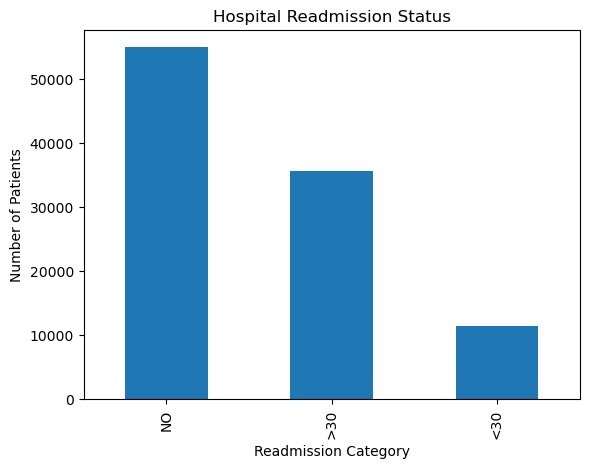

In [11]:
import matplotlib.pyplot as plt

readmit_counts = df['readmitted'].value_counts()

readmit_counts.plot(kind='bar')

plt.title('Hospital Readmission Status')
plt.xlabel('Readmission Category')
plt.ylabel('Number of Patients')

plt.show()

## Finding 2: Age and Readmission

Patients aged 70–90 years demonstrated consistently elevated readmission rates. The 20–30 age group showed the highest percentage of 30-day readmissions and warrants further investigation.

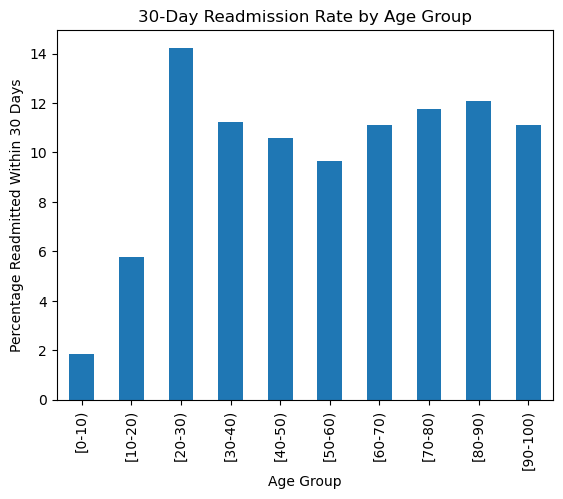

In [12]:
age_readmit = pd.crosstab(
    df['age'],
    df['readmitted'],
    normalize='index'
) * 100

age_readmit['<30'].plot(kind='bar')

plt.title('30-Day Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage Readmitted Within 30 Days')
plt.show()

## Finding 3: Length of Stay

Patients readmitted within 30 days had longer average hospital stays than patients who were not readmitted.

In [13]:
df.groupby('readmitted')['time_in_hospital'].mean()

readmitted
<30    4.768249
>30    4.495541
NO     4.254429
Name: time_in_hospital, dtype: float64

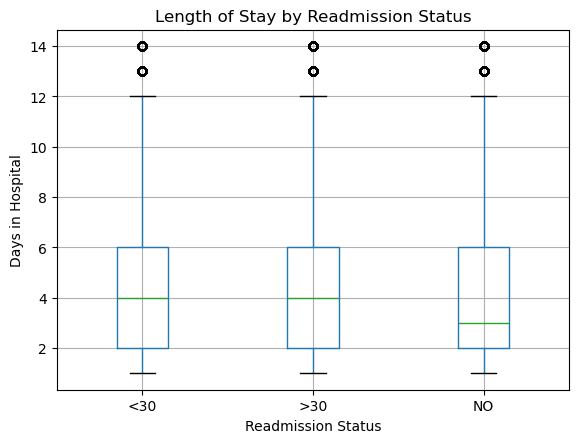

In [14]:
df.boxplot(column='time_in_hospital', by='readmitted')
plt.title('Length of Stay by Readmission Status')
plt.suptitle('')
plt.xlabel('Readmission Status')
plt.ylabel('Days in Hospital')
plt.show()

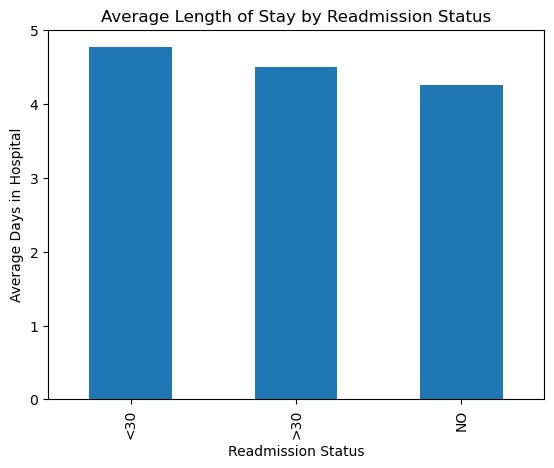

In [15]:
df.groupby('readmitted')['time_in_hospital'].mean().plot(kind='bar')

plt.title('Average Length of Stay by Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Average Days in Hospital')

plt.show()

## Finding 4: Previous Inpatient Admissions

Previous inpatient admissions showed a strong association with future readmission risk.

In [16]:
df.groupby('readmitted')['number_inpatient'].mean()

readmitted
<30    1.224003
>30    0.838993
NO     0.381963
Name: number_inpatient, dtype: float64

## Finding 5: Medication Burden

Patients who were readmitted tended to have a higher number of medications prescribed.

In [17]:
df.groupby('readmitted')['num_medications'].mean()

readmitted
<30    16.903143
>30    16.282768
NO     15.670367
Name: num_medications, dtype: float64

# Predictive Modeling

A Random Forest classifier was developed to predict patient readmission status.

In [24]:
df['readmitted_binary'] = df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

In [25]:
df['readmitted_binary'].value_counts()

readmitted_binary
0    54864
1    46902
Name: count, dtype: int64

In [26]:
features = [
    'time_in_hospital',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

X = df[features]
y = df['readmitted_binary']

In [27]:
df['readmitted'].unique()

array(['NO', '>30', '<30'], dtype=object)

In [28]:
df.groupby('readmitted')['number_emergency'].mean()

readmitted
<30    0.357313
>30    0.283669
NO     0.109216
Name: number_emergency, dtype: float64

In [29]:
df.groupby('readmitted')['number_outpatient'].mean()

readmitted
<30    0.436911
>30    0.496329
NO     0.273112
Name: number_outpatient, dtype: float64

In [30]:
df['readmitted_binary'] = df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

df['readmitted_binary'].value_counts()

readmitted_binary
0    54864
1    46902
Name: count, dtype: int64

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.5951164390291834


In [34]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
1,num_medications,0.395463
4,number_inpatient,0.237761
0,time_in_hospital,0.188709
2,number_outpatient,0.107414
3,number_emergency,0.070653


# Model Results

The model achieved an accuracy of 59.5%.

The most important predictors were:

1. Number of medications
2. Previous inpatient admissions
3. Length of hospital stay
4. Outpatient visits
5. Emergency visits

# Conclusion

This analysis identified several factors associated with hospital readmissions among diabetic patients. Medication burden, prior inpatient admissions, and length of stay emerged as important indicators of readmission risk.

These findings may help healthcare organizations identify high-risk patients and support targeted interventions aimed at reducing avoidable hospital readmissions.

In [37]:
readmission_counts = df['readmitted'].value_counts()

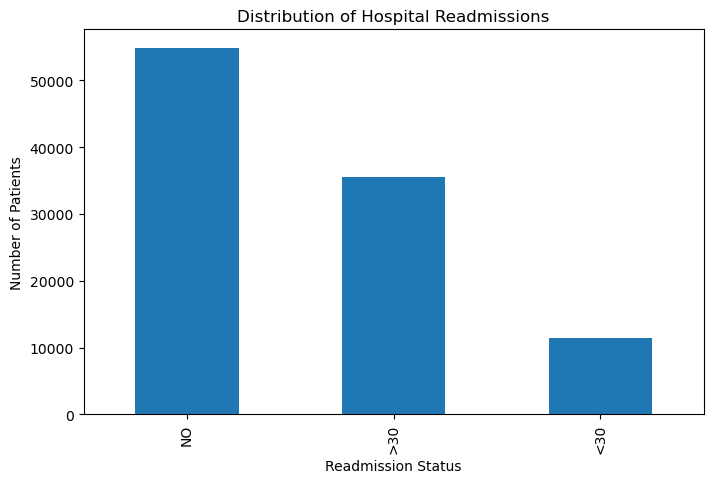

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

readmission_counts.plot(kind='bar')

plt.title('Distribution of Hospital Readmissions')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')

plt.savefig('../images/readmission_distribution.png')

plt.show()

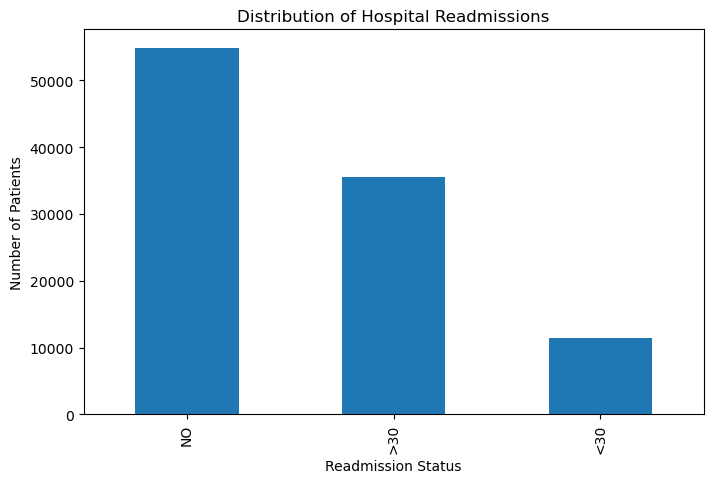

In [39]:
import matplotlib.pyplot as plt

readmission_counts = df['readmitted'].value_counts()

plt.figure(figsize=(8,5))

readmission_counts.plot(kind='bar')

plt.title('Distribution of Hospital Readmissions')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')

plt.savefig('../images/readmission_distribution.png')

plt.show()

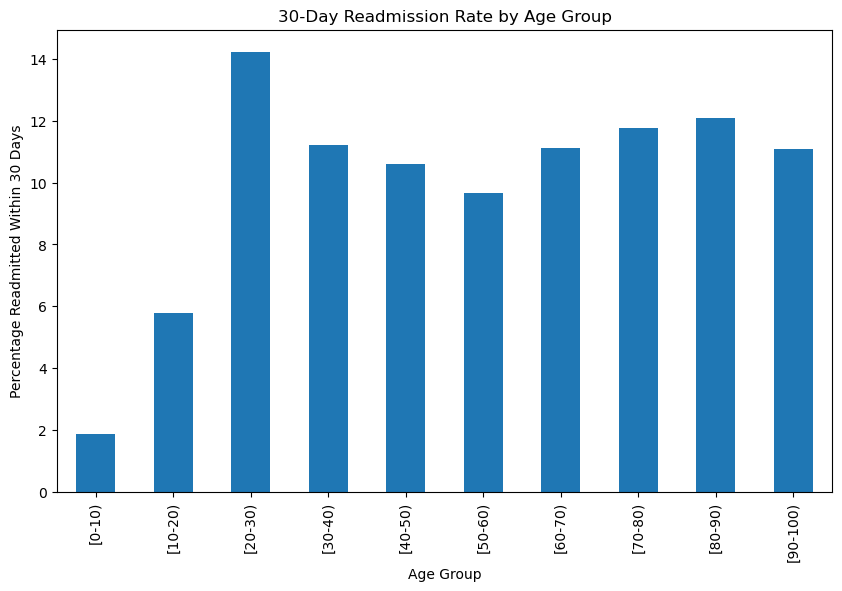

In [40]:
age_readmit = pd.crosstab(
    df['age'],
    df['readmitted'],
    normalize='index'
) * 100

plt.figure(figsize=(10,6))

age_readmit['<30'].plot(kind='bar')

plt.title('30-Day Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage Readmitted Within 30 Days')

plt.savefig('../images/age_vs_readmission.png')

plt.show()

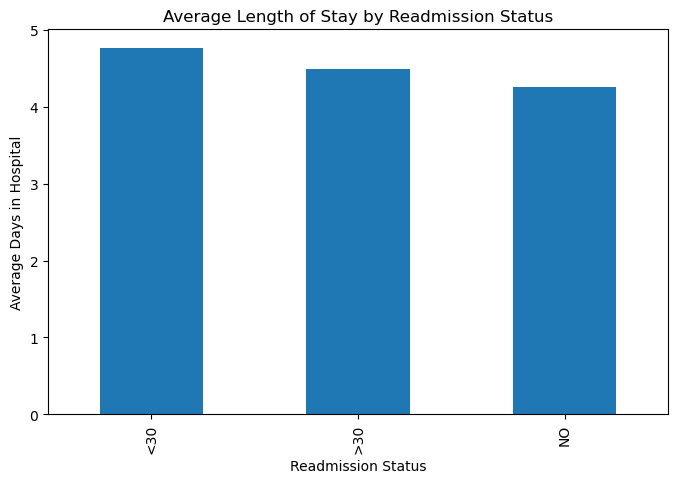

In [41]:
length_of_stay = df.groupby(
    'readmitted'
)['time_in_hospital'].mean()

plt.figure(figsize=(8,5))

length_of_stay.plot(kind='bar')

plt.title('Average Length of Stay by Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Average Days in Hospital')

plt.savefig('../images/length_of_stay.png')

plt.show()

In [42]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

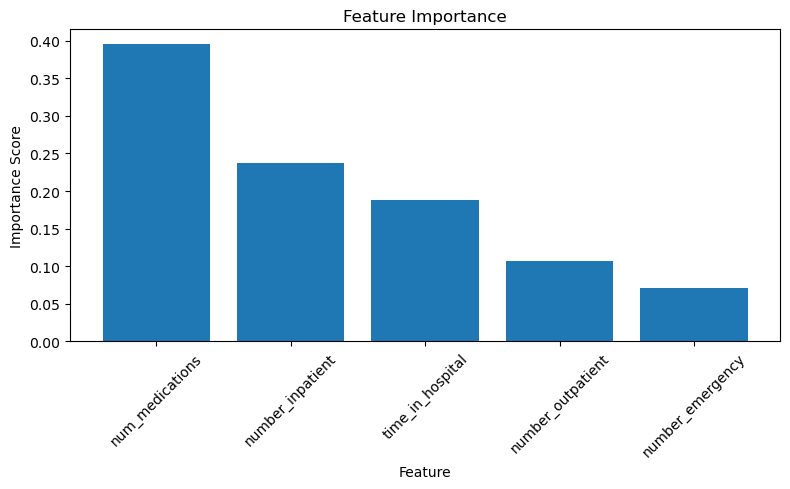

In [43]:
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance Score')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('../images/feature_importance.png')

plt.show()